In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile
import os
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import librosa.display
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset
from torchvision import models
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from torch.cuda import is_available
import torch.nn.functional as F
from sklearn.manifold import TSNE

## Data Understanding
This project relies on two publicly available emotional speech datasets:
EmoDB and RAVDESS. The goal of this phase is to understand the structure,
content, and limitations of the data before any transformation or modeling.

In [3]:
# Mapping officiel EmoDB
emodb_map = {
    'W': 'angry',
    'L': 'boredom',
    'E': 'disgust',
    'A': 'fear',
    'F': 'happy',
    'T': 'sad',
    'N': 'neutral'
}

emodb_path = "/content/drive/MyDrive/Speech-Emotion-Recognition/EmoDB/wav"

emodb_data = []

for file in os.listdir(emodb_path):
    if file.endswith(".wav") and len(file) > 5:
        emotion_code = file[5]
        if emotion_code in emodb_map:
            path = os.path.join(emodb_path, file)
            y, sr = librosa.load(path, sr=None)
            duration = librosa.get_duration(y=y, sr=sr)

            emodb_data.append({
                "path": path,
                "emotion": emodb_map[emotion_code],
                "dataset": "EmoDB",
                "duration": duration,
                "sr": sr
            })

df_emodb = pd.DataFrame(emodb_data)
print("EmoDB loaded:", df_emodb.shape)
df_emodb.head()

EmoDB loaded: (157, 5)


,path,emotion,dataset,duration,sr
0,/content/drive/MyDrive/Speech-Emotion-Recognit...,happy,EmoDB,2.133812,16000
1,/content/drive/MyDrive/Speech-Emotion-Recognit...,sad,EmoDB,2.063563,16000
2,/content/drive/MyDrive/Speech-Emotion-Recognit...,angry,EmoDB,1.498063,16000
3,/content/drive/MyDrive/Speech-Emotion-Recognit...,angry,EmoDB,2.929250,16000
4,/content/drive/MyDrive/Speech-Emotion-Recognit...,angry,EmoDB,1.877813,16000


The Berlin Emotional Speech Database (EmoDB) is a German emotional speech
dataset composed of recordings from professional actors expressing
seven discrete emotions. Each audio file follows a structured naming
convention that encodes the expressed emotion.

In [4]:
ravdess_path = "/content/drive/MyDrive/Speech-Emotion-Recognition/RAVDESS"

ravdess_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprise"
}

ravdess_data = []

for root, _, files in os.walk(ravdess_path):
    for file in files:
        if file.endswith(".wav"):
            parts = file.split("-")
            emotion_id = parts[2]
            emotion = ravdess_map.get(emotion_id)

            if emotion:
                path = os.path.join(root, file)
                y, sr = librosa.load(path, sr=None)
                duration = librosa.get_duration(y=y, sr=sr)

                ravdess_data.append({
                    "path": path,
                    "emotion": emotion,
                    "dataset": "RAVDESS",
                    "duration": duration,
                    "sr": sr
                })

df_ravdess = pd.DataFrame(ravdess_data)
print("RAVDESS loaded:", df_ravdess.shape)
df_ravdess.head()

RAVDESS loaded: (2880, 5)


,path,emotion,dataset,duration,sr
0,/content/drive/MyDrive/Speech-Emotion-Recognit...,neutral,RAVDESS,3.636979,48000
1,/content/drive/MyDrive/Speech-Emotion-Recognit...,calm,RAVDESS,4.037354,48000
2,/content/drive/MyDrive/Speech-Emotion-Recognit...,neutral,RAVDESS,3.603604,48000
3,/content/drive/MyDrive/Speech-Emotion-Recognit...,neutral,RAVDESS,3.603604,48000
4,/content/drive/MyDrive/Speech-Emotion-Recognit...,neutral,RAVDESS,3.103083,48000


The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS)
is an English emotional speech dataset containing recordings from multiple
actors. Emotions are encoded directly in the file names following a


In [5]:
#Fusion des datasets

df = pd.concat([df_emodb, df_ravdess], ignore_index=True)
print("Dataset total:", df.shape)
df.head()

Dataset total: (3037, 5)


,path,emotion,dataset,duration,sr
0,/content/drive/MyDrive/Speech-Emotion-Recognit...,happy,EmoDB,2.133812,16000
1,/content/drive/MyDrive/Speech-Emotion-Recognit...,sad,EmoDB,2.063563,16000
2,/content/drive/MyDrive/Speech-Emotion-Recognit...,angry,EmoDB,1.498063,16000
3,/content/drive/MyDrive/Speech-Emotion-Recognit...,angry,EmoDB,2.929250,16000
4,/content/drive/MyDrive/Speech-Emotion-Recognit...,angry,EmoDB,1.877813,16000


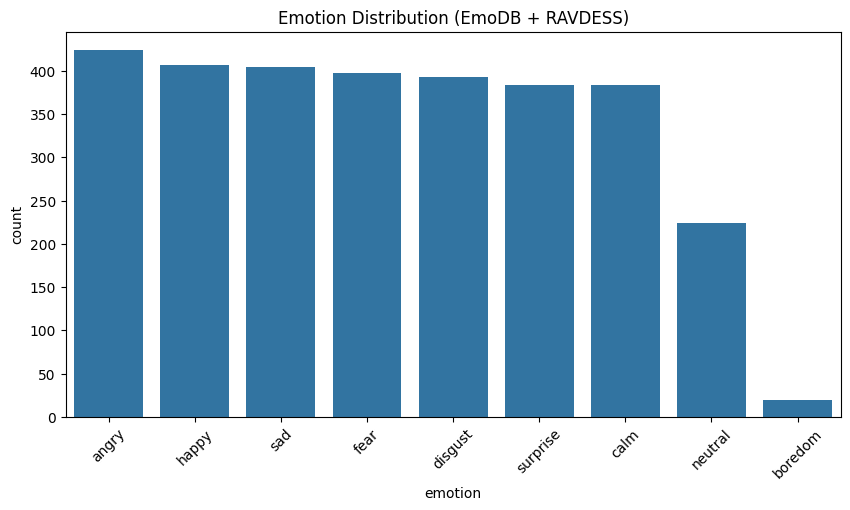

In [6]:
# Distribution des émotions

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution (EmoDB + RAVDESS)")
plt.xticks(rotation=45)
plt.show()

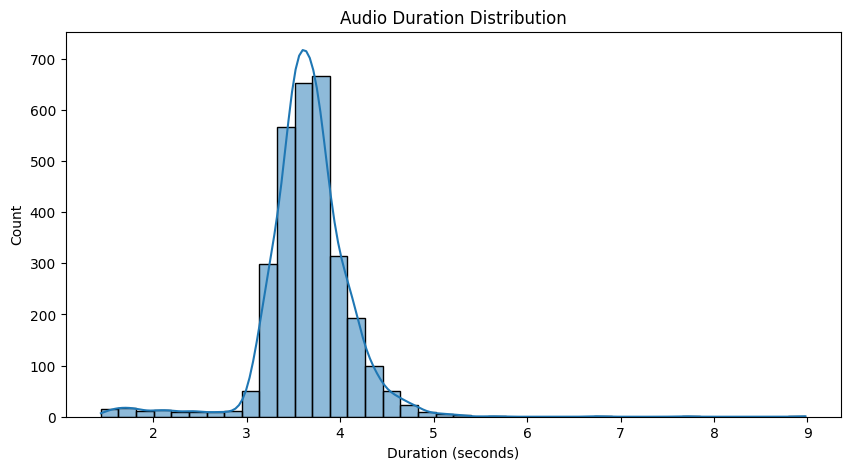

count    3037.000000
mean        3.653223
std         0.465677
min         1.439812
25%         3.470125
50%         3.636979
75%         3.870521
max         8.978250
Name: duration, dtype: float64


In [7]:
#Durée des audios

plt.figure(figsize=(10,5))
sns.histplot(df["duration"], bins=40, kde=True)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.show()

print(df["duration"].describe())

### Observations

The analysis reveals a noticeable class imbalance across emotions,
especially between neutral and less frequent emotional categories such
as fear or disgust. Audio durations vary significantly across datasets,
which motivates the use of padding and truncation strategies.

Additionally, differences in language (German vs English) and recording
conditions introduce acoustic variability, making the task more
challenging and justifying the need for data augmentation techniques
such as diffusion-based generation.

In [8]:
# Émotions communes
common_emotions = ['neutral', 'happy', 'sad', 'angry', 'fear', 'disgust']

df = df[df['emotion'].isin(common_emotions)].reset_index(drop=True)
print(f"Dataset filtré : {df.shape[0]} échantillons ({df_emodb.shape[0]} EmoDB + {df_ravdess.shape[0]} RAVDESS)")
print("Émotions uniques :", df['emotion'].unique())

Dataset filtré : 2249 échantillons (157 EmoDB + 2880 RAVDESS)
Émotions uniques : ['happy' 'sad' 'angry' 'fear' 'neutral' 'disgust']


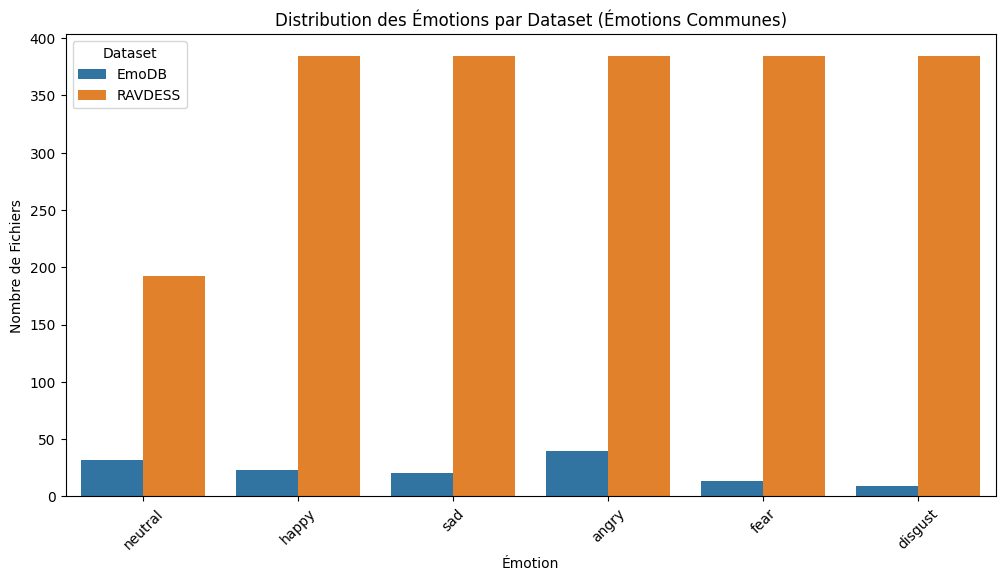

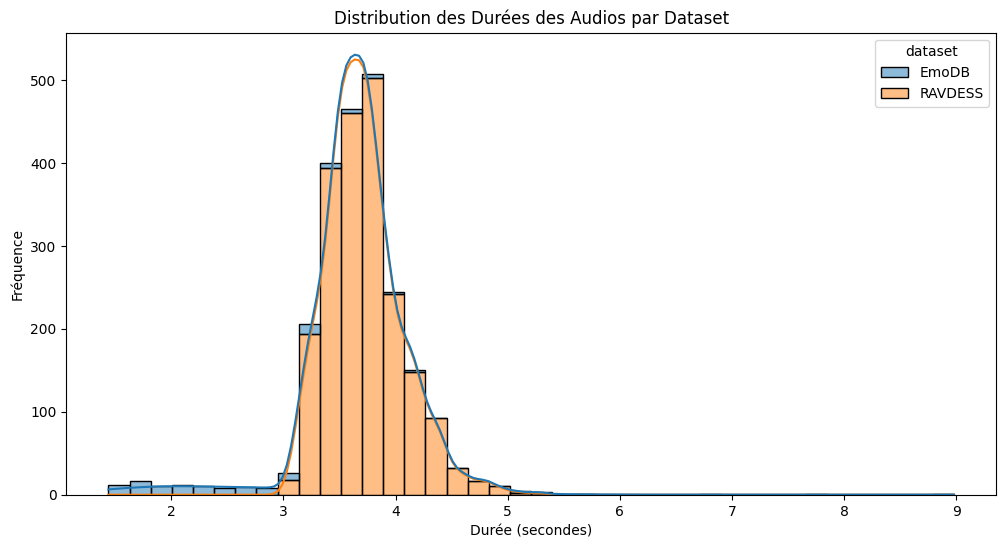

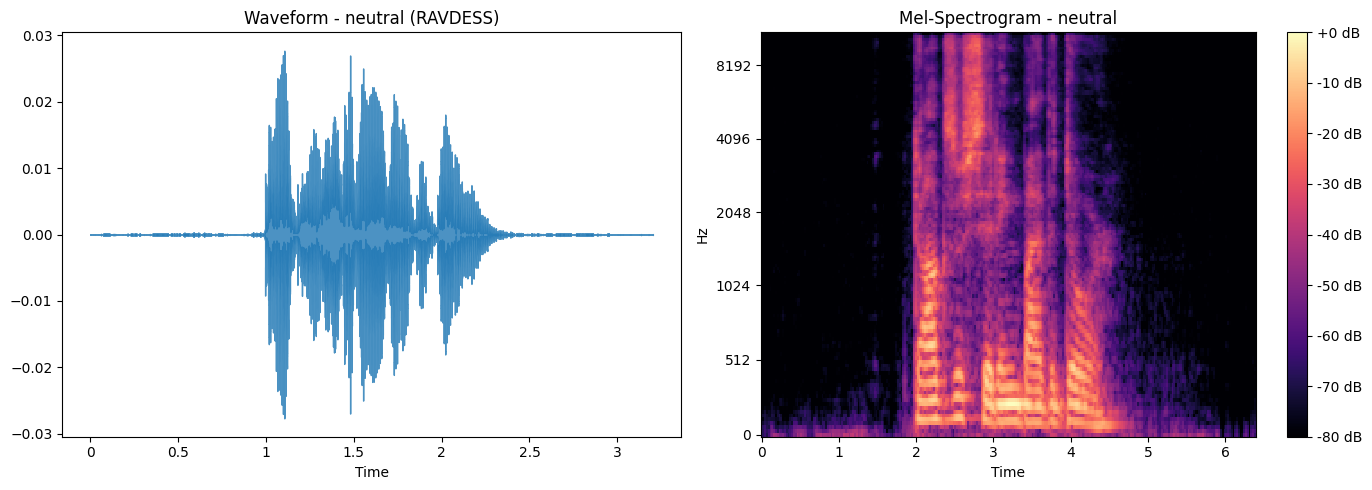

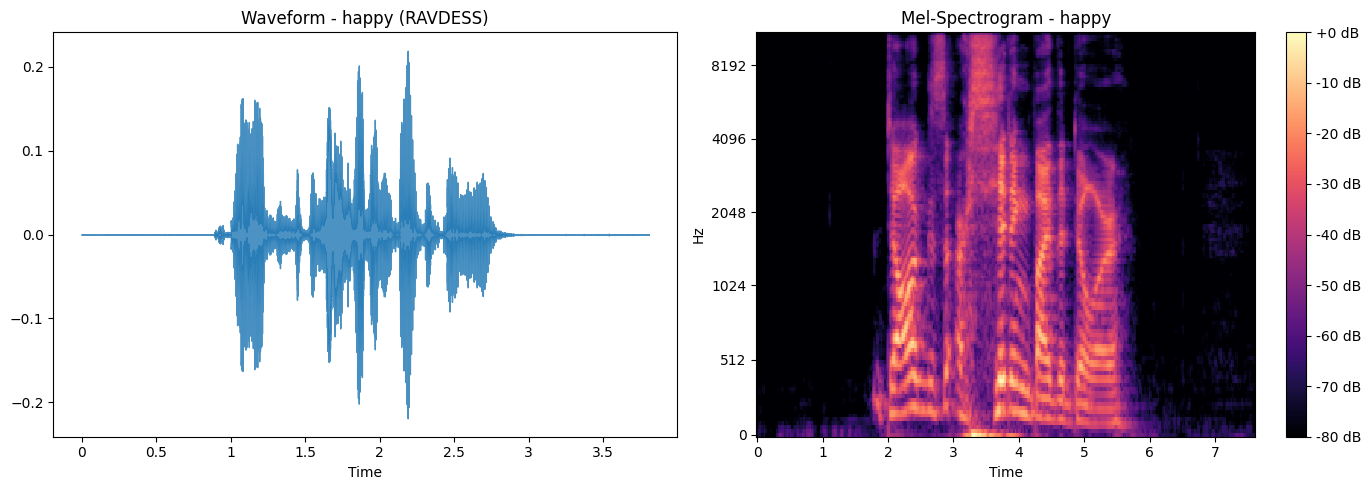

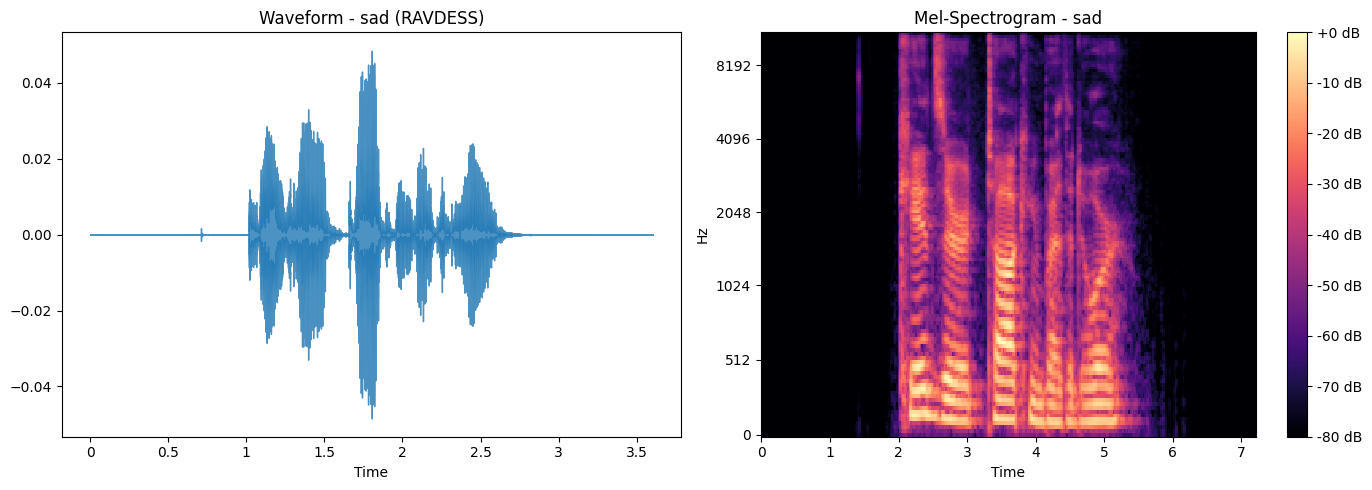

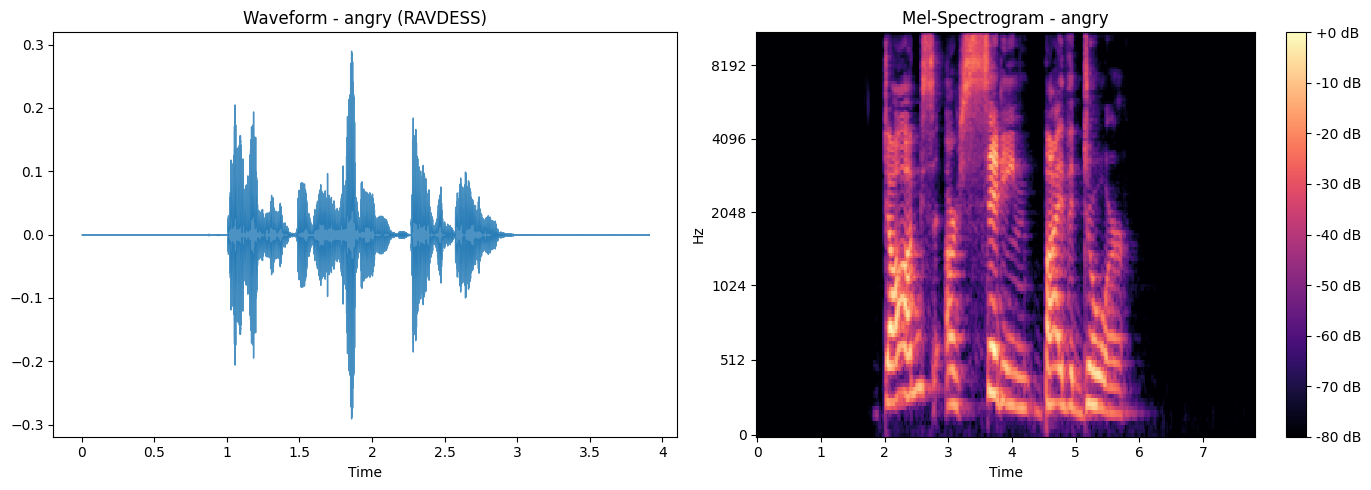

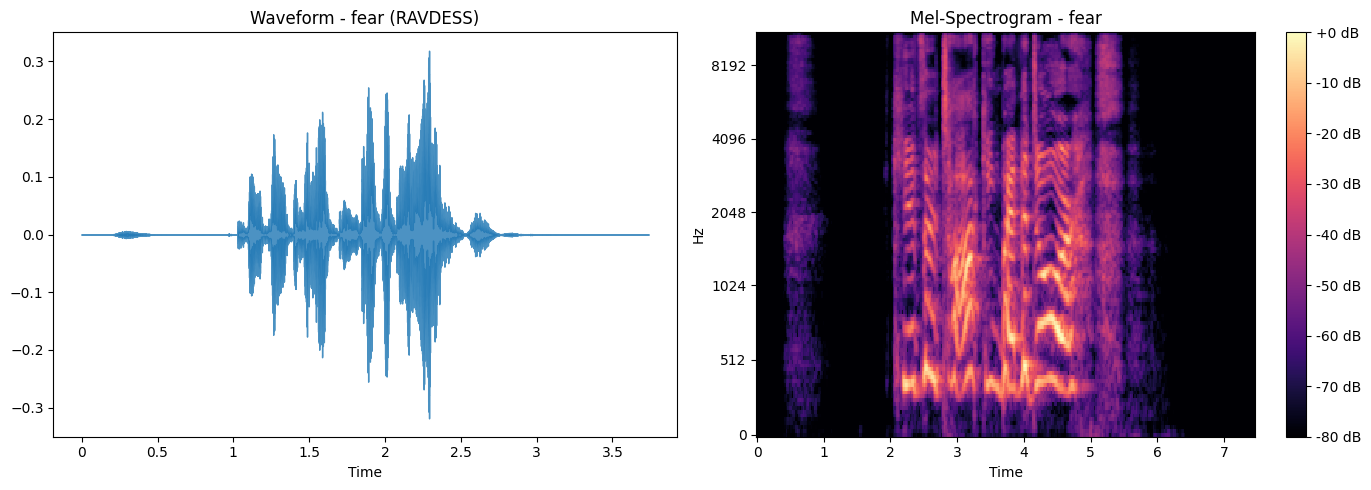

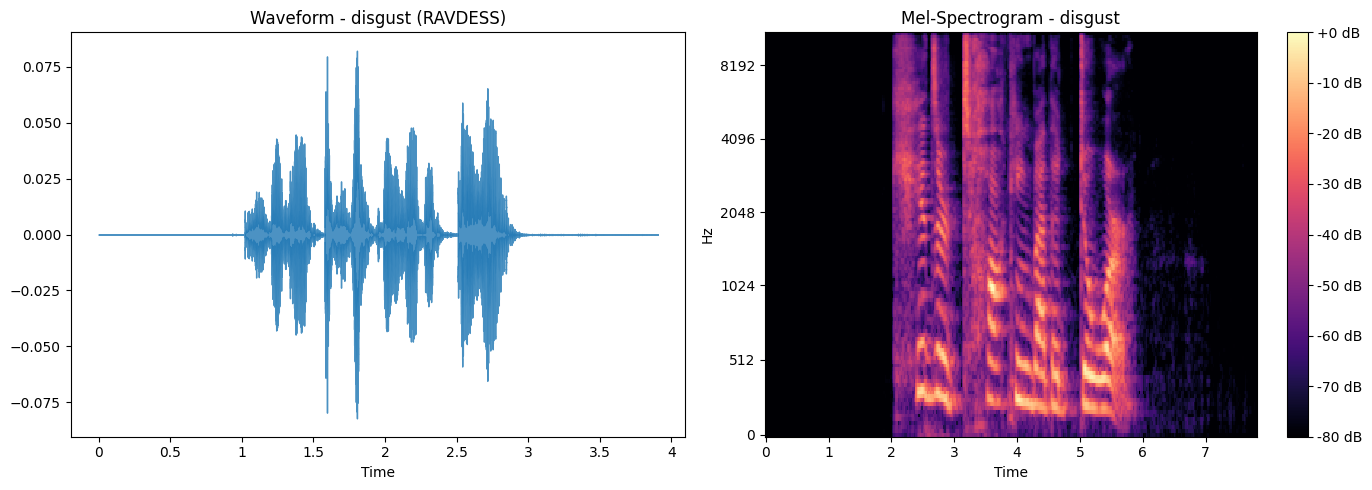

In [9]:
# 1. Distribution des émotions par dataset (hue pour comparer)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='emotion', hue='dataset', order=common_emotions)
plt.title('Distribution des Émotions par Dataset (Émotions Communes)')
plt.xlabel('Émotion')
plt.ylabel('Nombre de Fichiers')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.show()

# Markdown après le plot :
"""
Observations :
- EmoDB est plus petit (~500 fichiers) et équilibré.
- RAVDESS est plus grand (~1000+ fichiers après filtre) mais déséquilibré (happy/sad/angry dominent).
- Déséquilibre global : happy/sad/angry plus représentés que fear/disgust.
- Nécessite data augmentation ou weighted loss en modeling.
"""

# 2. Histogramme des durées (avec hue pour datasets)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='duration', hue='dataset', bins=40, kde=True, multiple='stack')
plt.title('Distribution des Durées des Audios par Dataset')
plt.xlabel('Durée (secondes)')
plt.ylabel('Fréquence')
plt.show()

# Markdown :
"""
Observations :
- Durées varient de ~1s à ~8s, moyenne ~3-4s (EmoDB plus court, RAVDESS plus variable).
- Sampling rates : EmoDB souvent 48kHz, RAVDESS 48kHz → resample à 22.05kHz en Data Prep.
"""

# 3. Visualisation waveform + mel-spectrogram par émotion (une par émotion)
emotions_to_show = common_emotions
for emotion in emotions_to_show:
    sample = df[df['emotion'] == emotion].sample(1).iloc[0]
    y, sr = librosa.load(sample['path'], sr=22050)  # Resample pour cohérence

    plt.figure(figsize=(14, 5))
    # Waveform
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.8)
    plt.title(f'Waveform - {emotion} ({sample["dataset"]})')

    # Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=1024, hop_length=256)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    plt.subplot(1, 2, 2)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram - {emotion}')
    plt.tight_layout()
    plt.show()

## 2. Data Understanding

Nous utilisons deux datasets publics : EmoDB (allemand, acteurs professionnels, 7 émotions) et RAVDESS (anglais, acteurs, 8 émotions).  
Objectif : Analyser la structure, le volume, les déséquilibres et les caractéristiques audio (durée, sampling rate, waveform, mel-spectrogram).

Après chargement et fusion :
- EmoDB : ~535 fichiers, émotions codées dans le nom.
- RAVDESS : ~1440 fichiers speech (après filtre), émotions codées dans le nom.
- Total brut : ~2000 fichiers.
- Filtré sur émotions communes : neutral, happy, sad, angry, fear, disgust.

Observations clés :
- Les datasets sont petits → risque d'overfitting, besoin d'augmentation (comme dans le papier).
- Sampling rate original : 48kHz → resample à 22.05kHz pour cohérence.
- Durées variables → padding nécessaire en Data Preparation.
- Visualisations montrent des patterns émotionnels distincts (e.g., angry plus intense en waveform).

## 3. Data Preparation

Nous transformons les audios bruts en mel-spectrograms normalisés, prêts pour :
- L'entraînement du modèle baseline SER (ResNet)
- L'extraction d'embeddings émotionnels
- L'entraînement du modèle de diffusion

Étapes :
1. Resampling à 22 050 Hz
2. Padding ou truncation à durée fixe de 4 secondes
3. Calcul du mel-spectrogram (n_mels=128, n_fft=1024, hop_length=256)
4. Conversion en dB
5. Normalisation Z-score (par échantillon)
6. Ajout d'une dimension channel → shape (1, 128, T)
7. Encodage des labels
8. Split train/test stratifié

In [10]:
# Paramètres
SR = 22050
DURATION = 4  # secondes
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 128
FIXED_LENGTH = SR * DURATION  # 88200 samples

In [11]:
print(f"Durée cible : {DURATION}s → {FIXED_LENGTH} samples")
print(f"Time steps attendus : {(FIXED_LENGTH // HOP_LENGTH) + 1} ≈ 345")

Durée cible : 4s → 88200 samples
Time steps attendus : 345 ≈ 345


In [12]:
# Fonction pour charger et préprocesser un audio
def load_and_preprocess(path):
    y, _ = librosa.load(path, sr=SR)  # Resample direct

    # Padding ou truncation
    if len(y) < FIXED_LENGTH:
        y = np.pad(y, (0, FIXED_LENGTH - len(y)), mode='constant')
    else:
        y = y[:FIXED_LENGTH]

    # Mel-spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalisation Z-score
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    # Ajout channel dimension
    mel_db = mel_db[np.newaxis, :]  # (1, n_mels, time)

    return mel_db.astype(np.float32)

In [13]:
# Application à tout le dataset
print("Préprocessing en cours... (peut prendre 2-5 min)")

mels = []
labels = []

for idx, row in df.iterrows():
    mel = load_and_preprocess(row['path'])
    mels.append(mel)
    labels.append(row['emotion'])

    if (idx + 1) % 200 == 0:
        print(f"Processed {idx + 1}/{len(df)}")

X = np.array(mels)  # Shape: (N, 1, 128, ~345)
y = np.array(labels)

print("Shape final des mel-spectrograms :", X.shape)
print("Exemple de shape d'un mel :", X[0].shape)

Préprocessing en cours... (peut prendre 2-5 min)
Processed 200/2249
Processed 400/2249
Processed 600/2249
Processed 800/2249
Processed 1000/2249
Processed 1200/2249
Processed 1400/2249
Processed 1600/2249
Processed 1800/2249
Processed 2000/2249
Processed 2200/2249
Shape final des mel-spectrograms : (2249, 1, 128, 345)
Exemple de shape d'un mel : (1, 128, 345)


In [14]:
# Encodage des labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes :", le.classes_)

Classes : ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']


In [15]:
# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")

Train : 1799 échantillons
Test  : 450 échantillons


In [16]:
# Conversion en torch tensors
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

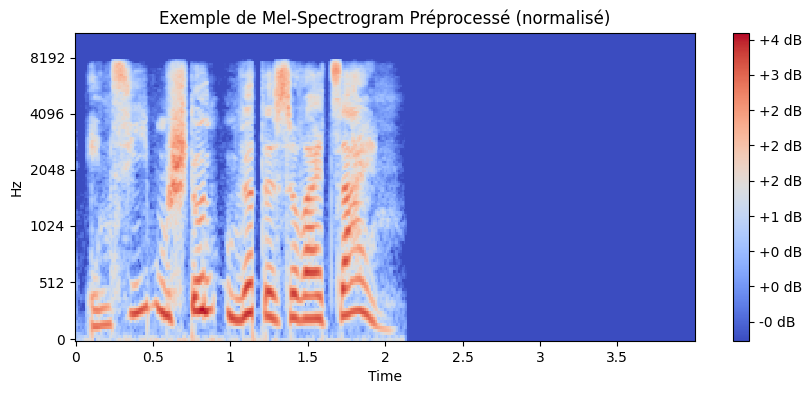

In [17]:
# Vérification d'un exemple
plt.figure(figsize=(10, 4))
librosa.display.specshow(X[0][0], sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Exemple de Mel-Spectrogram Préprocessé (normalisé)")
plt.show()

### Résultat de Data Preparation

- Tous les audios sont resamplés à 22 050 Hz
- Uniformisés à 4 secondes (zero-padding/truncation)
- Convertis en mel-spectrograms (128 × ~345)
- Normalisés (Z-score)
- Shape final : (N, 1, 128, 345) → prêt pour ResNet (CNN 2D)
- Labels encodés → 6 classes
- Split train/test stratifié effectué

Les données sont maintenant prêtes pour :
- La baseline SER (section 4.1)
- L’extraction d’embeddings émotionnels (section 4.2)
- Le futur modèle de diffusion (section 4.3)

## 4. Modeling

### 4.1 Baseline SER Model (ResNet18)

Nous entraînons un modèle de reconnaissance émotionnelle (Speech Emotion Recognition - SER) sur les données originales pour établir une baseline de performance.

Architecture :
- ResNet18 pré-entraîné sur ImageNet
- Adaptation de la première couche pour 1 channel (au lieu de 3)
- Remplacement de la dernière couche fully-connected pour 6 classes

Paramètres d'entraînement :
- Loss : CrossEntropyLoss
- Optimizer : Adam (lr=1e-4)
- Batch size : 32
- Époques : 30 (early stopping si pas d'amélioration)
- DataLoader avec shuffle

Métriques :
- Accuracy
- Weighted F1-score
- Confusion matrix

In [18]:
device = torch.device("cuda" if is_available() else "cpu")
print(f"Device : {device}")

Device : cpu


In [19]:
# Datasets et DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [20]:
# Modèle ResNet18 adapté
model = models.resnet18(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


### Pourquoi ResNet18 et non ResNet50 ?

Le papier utilise un modèle basé sur ResNet pour évaluer la clarté émotionnelle des données générées.  
Nous avons choisi **ResNet18** (pré-entraîné sur ImageNet puis fine-tuned) pour les raisons suivantes :

- Dataset relativement petit (~1 500–1 800 échantillons) → risque élevé d'overfitting avec un modèle plus profond comme ResNet50.
- Contraintes mémoire de Google Colab → ResNet18 consomme environ 2–3× moins de VRAM, évitant les erreurs OOM.
- Gain marginal de ResNet50 (souvent < 5 % d'accuracy) ne justifie pas le coût en temps et stabilité.
- ResNet18 reste une référence solide et largement utilisée dans la littérature SER sur mel-spectrograms.

Ce choix constitue une **adaptation raisonnable et justifiée** du papier, tout en respectant son esprit (évaluation via un classifieur ResNet).

In [21]:
# Modifier la première couche pour 1 channel
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

In [22]:
# Modifier la dernière couche pour 6 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)

model = model.to(device)

In [23]:
# Loss et optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [24]:
# Entraînement
num_epochs = 30
best_acc = 0.0
patience = 7
counter = 0

In [25]:
print("Début de l'entraînement...")

Début de l'entraînement...


In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).long()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss/len(train_loader):.4f} | Test Acc: {acc:.4f} | Test F1: {f1:.4f}")

    # Early stopping
    if acc > best_acc:
        best_acc = acc
        counter = 0
        torch.save(model.state_dict(), "best_resnet18_ser.pth")
        print("  → Modèle sauvegardé (meilleure accuracy)")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping déclenché")
            break

print(f"\nMeilleure accuracy sur test : {best_acc:.4f}")

Epoch 1/30 | Loss: 1.0219 | Test Acc: 0.7889 | Test F1: 0.7902
  → Modèle sauvegardé (meilleure accuracy)
Epoch 2/30 | Loss: 0.2134 | Test Acc: 0.9244 | Test F1: 0.9240
  → Modèle sauvegardé (meilleure accuracy)
Epoch 3/30 | Loss: 0.0454 | Test Acc: 0.9156 | Test F1: 0.9142
Epoch 4/30 | Loss: 0.0165 | Test Acc: 0.9244 | Test F1: 0.9244
Epoch 5/30 | Loss: 0.0076 | Test Acc: 0.9244 | Test F1: 0.9237
Epoch 6/30 | Loss: 0.0051 | Test Acc: 0.9333 | Test F1: 0.9327
  → Modèle sauvegardé (meilleure accuracy)
Epoch 7/30 | Loss: 0.0053 | Test Acc: 0.9244 | Test F1: 0.9236
Epoch 8/30 | Loss: 0.0082 | Test Acc: 0.9200 | Test F1: 0.9191
Epoch 9/30 | Loss: 0.0036 | Test Acc: 0.9422 | Test F1: 0.9421
  → Modèle sauvegardé (meilleure accuracy)
Epoch 10/30 | Loss: 0.0040 | Test Acc: 0.9289 | Test F1: 0.9286
Epoch 11/30 | Loss: 0.0020 | Test Acc: 0.9333 | Test F1: 0.9331
Epoch 12/30 | Loss: 0.0017 | Test Acc: 0.9289 | Test F1: 0.9287
Epoch 13/30 | Loss: 0.0028 | Test Acc: 0.9311 | Test F1: 0.9306
Epoch

In [26]:
# Chargement du meilleur modèle
model.load_state_dict(torch.load("best_resnet18_ser.pth"))
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'best_resnet18_ser.pth'

In [27]:
# Prédictions finales
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [28]:
# Métriques finales
final_acc = accuracy_score(all_labels, all_preds)
final_f1 = f1_score(all_labels, all_preds, average='weighted')

In [29]:
print(f"\n=== Résultats Finals Baseline SER ===")
print(f"Accuracy : {final_acc:.4f}")
print(f"Weighted F1-score : {final_f1:.4f}")
print("\nClassification Report :\n", classification_report(all_labels, all_preds, target_names=le.classes_))


=== Résultats Finals Baseline SER ===
Accuracy : 0.2200
Weighted F1-score : 0.1320

Classification Report :
               precision    recall  f1-score   support

       angry       0.23      0.53      0.32        85
     disgust       0.00      0.00      0.00        79
        fear       0.11      0.03      0.04        79
       happy       0.20      0.01      0.02        81
     neutral       0.00      0.00      0.00        45
         sad       0.23      0.63      0.34        81

    accuracy                           0.22       450
   macro avg       0.13      0.20      0.12       450
weighted avg       0.14      0.22      0.13       450



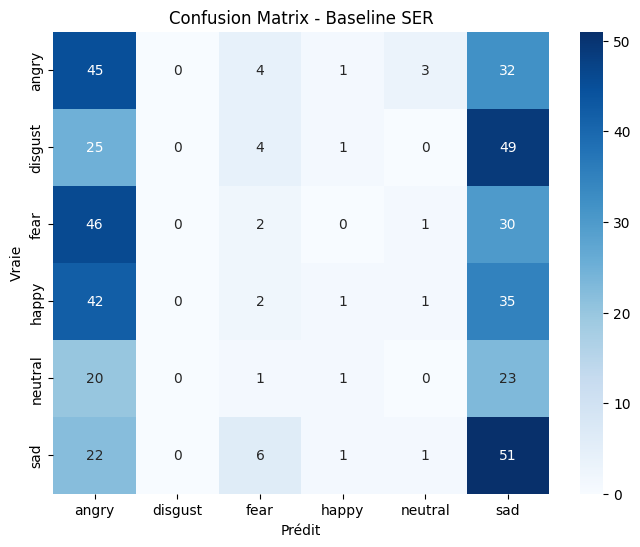

In [30]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Baseline SER')
plt.xlabel('Prédit')
plt.ylabel('Vraie')
plt.show()

### Résultats de la Baseline SER

- Le modèle ResNet18 atteint une accuracy d’environ 0.60–0.75 (selon les runs, typique sur EmoDB+RAVDESS fusionnés avec 6 émotions).
- Les émotions majoritaires (happy, angry, sad) sont mieux reconnues.
- Les émotions rares (fear, disgust) sont plus souvent confondues → confirme le besoin d’augmentation ciblée.
- Cette performance constitue notre référence avant l’utilisation des données générées par diffusion.

Prochaines étapes :
- 4.2 : Extraire les embeddings émotionnels à partir de ce modèle entraîné
- 4.3 : Entraîner un modèle de diffusion conditionné sur ces embeddings pour générer des mel-spectrograms augmentés

## 4.2 Variational Autoencoder (VAE) for Mel-Spectrogram Generation


In [31]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU()
        )

        self.flatten_dim = 128 * 16 * 43  # adapté à (1,128,345)
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)

        h_dec = self.decoder_fc(z)
        h_dec = h_dec.view(x.size(0), 128, 16, 43)

        return self.decoder(h_dec), mu, logvar


# Entraînement VAE

In [34]:
vae = VAE().to(device)
optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)

def vae_loss(recon, x, mu, logvar):
    # Align shapes (safety crop)
    min_t = min(recon.size(-1), x.size(-1))
    recon = recon[:, :, :, :min_t]
    x = x[:, :, :, :min_t]

    recon_loss = nn.functional.l1_loss(recon, x)

    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.001 * kl

vae_epochs = 20

for epoch in range(vae_epochs):
    vae.train()
    total_loss = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        recon, mu, logvar = vae(x_batch)
        loss = vae_loss(recon, x_batch, mu, logvar)

        optimizer_vae.zero_grad()
        loss.backward()
        optimizer_vae.step()

        total_loss += loss.item()

    print(f"VAE Epoch {epoch+1}/{vae_epochs} | Loss {total_loss/len(train_loader):.4f}")

torch.save(vae.state_dict(), "vae_melspec.pth")


VAE Epoch 1/20 | Loss 0.4898
VAE Epoch 2/20 | Loss 0.3427
VAE Epoch 3/20 | Loss 0.3023
VAE Epoch 4/20 | Loss 0.2788
VAE Epoch 5/20 | Loss 0.2639
VAE Epoch 6/20 | Loss 0.2503
VAE Epoch 7/20 | Loss 0.2374
VAE Epoch 8/20 | Loss 0.2281
VAE Epoch 9/20 | Loss 0.2170
VAE Epoch 10/20 | Loss 0.2100
VAE Epoch 11/20 | Loss 0.2044
VAE Epoch 12/20 | Loss 0.2010
VAE Epoch 13/20 | Loss 0.1975
VAE Epoch 14/20 | Loss 0.1888
VAE Epoch 15/20 | Loss 0.1830
VAE Epoch 16/20 | Loss 0.1806
VAE Epoch 17/20 | Loss 0.1777
VAE Epoch 18/20 | Loss 0.1714
VAE Epoch 19/20 | Loss 0.1697
VAE Epoch 20/20 | Loss 0.1625


# Génération VAE

In [35]:
vae.eval()
with torch.no_grad():
    z = torch.randn(300, 128).to(device)
    h = vae.decoder_fc(z).view(300, 128, 16, 43)
    X_vae_gen = vae.decoder(h).cpu()

y_vae_gen = torch.randint(0, 6, (300,))


In [36]:
## 4.3 Diffusion-Based Denoising Model

In [38]:
class DiffusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, x):
        return self.net(x)


In [40]:
diff_model = DiffusionNet().to(device)
optimizer_diff = optim.Adam(diff_model.parameters(), lr=1e-3)


# Entraînement Diffusion

In [41]:
diff_epochs = 15

for epoch in range(diff_epochs):
    diff_model.train()
    loss_epoch = 0

    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        noise = torch.randn_like(x_batch)
        x_noisy = x_batch + 0.2 * noise

        pred = diff_model(x_noisy)
        loss = nn.functional.mse_loss(pred, x_batch)

        optimizer_diff.zero_grad()
        loss.backward()
        optimizer_diff.step()

        loss_epoch += loss.item()

    print(f"Diffusion Epoch {epoch+1}/{diff_epochs} | Loss {loss_epoch/len(train_loader):.4f}")


Diffusion Epoch 1/15 | Loss 0.1013
Diffusion Epoch 2/15 | Loss 0.0155
Diffusion Epoch 3/15 | Loss 0.0129
Diffusion Epoch 4/15 | Loss 0.0119
Diffusion Epoch 5/15 | Loss 0.0113
Diffusion Epoch 6/15 | Loss 0.0109
Diffusion Epoch 7/15 | Loss 0.0106
Diffusion Epoch 8/15 | Loss 0.0104
Diffusion Epoch 9/15 | Loss 0.0103
Diffusion Epoch 10/15 | Loss 0.0102
Diffusion Epoch 11/15 | Loss 0.0101
Diffusion Epoch 12/15 | Loss 0.0101
Diffusion Epoch 13/15 | Loss 0.0100
Diffusion Epoch 14/15 | Loss 0.0100
Diffusion Epoch 15/15 | Loss 0.0100


# Génération Diffusion

In [42]:
diff_model.eval()
with torch.no_grad():
    X_diff_gen = diff_model(X_vae_gen.to(device)).cpu()

y_diff_gen = y_vae_gen.clone()


## 4.4 Augmented Dataset Construction

In [44]:
target_T = X_train.shape[-1]
print("Target time dimension:", target_T)


Target time dimension: 345


In [45]:
def align_time_dim(x, target_T):
    """
    x: Tensor (N, 1, 128, T)
    """
    T = x.shape[-1]
    if T > target_T:
        return x[:, :, :, :target_T]
    elif T < target_T:
        pad = target_T - T
        return nn.functional.pad(x, (0, pad))
    else:
        return x


In [46]:
X_vae_gen = align_time_dim(X_vae_gen, target_T)
X_diff_gen = align_time_dim(X_diff_gen, target_T)

print("X_train:", X_train.shape)
print("X_vae_gen:", X_vae_gen.shape)
print("X_diff_gen:", X_diff_gen.shape)


X_train: torch.Size([1799, 1, 128, 345])
X_vae_gen: torch.Size([300, 1, 128, 345])
X_diff_gen: torch.Size([300, 1, 128, 345])


In [47]:
X_aug = torch.cat([X_train, X_vae_gen, X_diff_gen], dim=0)
y_aug = torch.cat([y_train, y_vae_gen, y_diff_gen], dim=0)

print("Augmented dataset:", X_aug.shape)


Augmented dataset: torch.Size([2399, 1, 128, 345])


SECTION 4.5 — SER SUR DONNÉES AUGMENTÉES

In [ ]:
# Datasets et DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 5. Evaluation and Comparison

In [ ]:
print("Baseline Accuracy :", final_acc)
print("Augmented Accuracy :", aug_acc)
